In [2]:
import pandas as pd
import numpy as np
import warnings

In [22]:
df=pd.read_csv('./dataset/cleaned_enron_v6 2.csv')
print(f"shape:{df.shape}")
df.head()

shape:(115773, 2)


,subject,body
0,no subject,travel business meeting take fun trip . especi...
1,no subject,randy send schedule salary level everyone sche...
2,no subject,please cc following distribution list update p...
3,fw fix forward collar floor gas price term,mr. buckner deliver gas behind san diego enron...
4,no subject,lucy rentrolls open save rentroll folder . fol...


In [4]:
import re

def clean_text(text):
    """Normalise a single string: lowercase, strip noise, collapse whitespace."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove special chars — keep letters, digits, spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to both columns
df['subject_clean'] = df['subject'].apply(clean_text)
df['body_clean']    = df['body'].apply(clean_text)

# Replace placeholder 'no_subject' with empty string
df['subject_clean'] = df['subject_clean'].replace('no subject', '')
df['subject_clean'] = df['subject_clean'].replace('no_subject', '')

# Combine subject + body  (subject weighted 3x — it's a strong signal)
df['text'] = (df['subject_clean'] + ' ') * 3 + df['body_clean']
df['text'] = df['text'].str.strip()

# Drop rows where combined text is empty or too short
df = df[df['text'].str.len() > 20].reset_index(drop=True)

print(f'After cleaning: {df.shape[0]:,} rows')
df[['subject_clean', 'body_clean', 'text']].head(3)

After cleaning: 115,773 rows


,subject_clean,body_clean,text
0,,travel business meeting take fun trip especial...,travel business meeting take fun trip especial...
1,,randy send schedule salary level everyone sche...,randy send schedule salary level everyone sche...
2,,please cc following distribution list update p...,please cc following distribution list update p...


In [5]:
df.head(5)

,subject,body,subject_clean,body_clean,text
0,no subject,travel business meeting take fun trip . especi...,,travel business meeting take fun trip especial...,travel business meeting take fun trip especial...
1,no subject,randy send schedule salary level everyone sche...,,randy send schedule salary level everyone sche...,randy send schedule salary level everyone sche...
2,no subject,please cc following distribution list update p...,,please cc following distribution list update p...,please cc following distribution list update p...
3,fw fix forward collar floor gas price term,mr. buckner deliver gas behind san diego enron...,fw fix forward collar floor gas price term,mr buckner deliver gas behind san diego enron ...,fw fix forward collar floor gas price term fw ...
4,no subject,lucy rentrolls open save rentroll folder . fol...,,lucy rentrolls open save rentroll folder follo...,lucy rentrolls open save rentroll folder follo...


In [6]:
import nltk
nltk.download('punkt_tab') 
nltk.download('averaged_perceptron_tagger_eng')  # newer NLTK needs _eng suffix
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
tqdm.pandas()

STOP_WORDS = set(stopwords.words('english'))
# Keep negations and key words that signal urgency/approval etc.
KEEP_WORDS = {'no', 'not', 'urgent', 'please', 'confirm', 'approve', 'pending',
              'asap', 'deadline', 'immediately', 'overdue', 'reminder', 'meeting',
              'schedule', 'birthday', 'happy', 'congratulation', 'newsletter',
              'follow', 'up', 'action', 'required', 'review', 'approve', 'request'}
STOP_WORDS -= KEEP_WORDS

lemmatizer = WordNetLemmatizer()

def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t.isalpha() and t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Tokenizing & lemmatizing... (may take 2-4 min on 192K rows)')
df['text_processed'] = df['text'].progress_apply(tokenize_and_lemmatize)

# Drop rows that became empty after processing
df = df[df['text_processed'].str.len() > 10].reset_index(drop=True)
print(f'After NLP processing: {df.shape[0]:,} rows')
df[['text', 'text_processed']].head(3)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HarshMaheshAgrawal\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HarshMaheshAgrawal\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Tokenizing & lemmatizing... (may take 2-4 min on 192K rows)


100%|██████████| 115773/115773 [00:27<00:00, 4269.20it/s]

After NLP processing: 115,773 rows


,text,text_processed
0,travel business meeting take fun trip especial...,travel business meeting take fun trip especial...
1,randy send schedule salary level everyone sche...,randy send schedule salary level everyone sche...
2,please cc following distribution list update p...,please following distribution list update phil...


In [7]:
LABEL_RULES = {
    'Urgent': [
        'urgent', 'asap', 'immediately', 'critical', 'emergency',
        'alert', 'action required', 'deadline', 'expires', 'expiring',
        'severe', 'high priority', 'important notice', 'failure', 'warn'
    ],
    'Approvals': [
        'approval', 'approve', 'approved', 'request access', 'access request',
        'permission', 'authorization', 'authorize', 'consent', 'sign off',
        'signoff', 'confirm', 'confirmation', 'please review', 'need approval',
        'require approval', 'overdue access'
    ],
    'Meetings': [
        'meeting', 'conference', 'call schedule', 'scheduled call',
        'please join', 'dial in', 'conference call', 'video call',
        'calendar invite', 'appointment', 'agenda', 'zoom', 'teams call',
        'let meet', 'meet tomorrow', 'meet today', 'round table'
    ],
    'Newsletters': [
        'newsletter', 'news today', 'industry news', 'daily digest',
        'weekly update', 'enron mention', 'market update', 'newscast',
        'press release', 'bulletin', 'subscription', 'unsubscribe',
        'morning briefing', 'energy news', 'rigzone', 'platts',
        'daily news', 'weekly digest', 'market report', 'oil gas news',
        'power news', 'commodity', 'subscribe', 'edition', 'headlines'
    ],
    'Birthdays': [
        'birthday', 'happy birthday', 'born', 'anniversary', 'celebrate',
        'congratulation', 'congrats', 'party', 'cake', 'wish', 'special day',
        'bday', 'many happy returns', 'best wishes', 'cheers', 'celebration',
        'born today', 'wishing you', 'have a great day'
    ],
    'Project_Followups': [
        'follow up', 'followup', 'status update', 'project update',
        'deliverable', 'milestone', 'progress', 'next step', 'action item',
        'task', 'tracker', 'report', 'performance', 'feedback', 'mid year'
    ],
    'Pending': [
        'pending', 'waiting', 'overdue', 'reminder', 'outstanding',
        'still waiting', 'have not heard', 'no response', 'please respond',
        'not yet', 'yet to', 'due date', 'past due', 'not received',
        'follow up', 'no reply', 'awaiting', 'please confirm receipt',
        'not responded', 'second reminder', 'third reminder', 'kindly revert',
        'haven t heard', 'checking in', 'any update',
        'get back to me', 'let me know', 'still need',
        'waiting on', 'following up', 'chasing',
        'can you confirm', 'have you had a chance',
        'when can', 'when will', 'by when',
        'not yet received', 'please update',
        'check in','follow', 'hear back','get back','let know','still need','wait',            
        'chase','pleas updat','any updat','updat pleas','when will',
        'when can','have chanc',   'not yet receiv','could you pleas',
        'pleas revert','kindli', 'gentl remind','just check',        
        'loop back','touch base','circl back', 
    ],
}

def assign_label(row):
    """Match subject first (higher signal), then body. Returns None if no match."""
    subj = str(row['subject_clean']).lower()
    body = str(row['text_processed']).lower()

    for label, keywords in LABEL_RULES.items():
        for kw in keywords:
            if kw in subj:
                return label

    for label, keywords in LABEL_RULES.items():
        for kw in keywords:
            if kw in body:
                return label

    return None   # ← no match — will be dropped

print('Assigning labels...')
df['label'] = df.progress_apply(assign_label, axis=1)

# ── Drop unmatched rows (previously "Other") ──────────────────────
total_before = len(df)
df = df[df['label'].notna()].reset_index(drop=True)
total_after = len(df)

print(f'\nDropped {total_before - total_after:,} unmatched rows '
      f'({(total_before - total_after)/total_before:.1%} of data)')
print(f'Retained: {total_after:,} rows\n')

print('Label distribution:')
print(df['label'].value_counts())

# ── Sanity check — warn if any category is too small ─────────────
print('\nHealth check:')
for label, count in df['label'].value_counts().items():
    status = '✅' if count >= 500 else '⚠️  LOW'
    print(f'  {status}  {label}: {count:,}')

Assigning labels...


100%|██████████| 115773/115773 [00:06<00:00, 18066.38it/s]


Dropped 47,238 unmatched rows (40.8% of data)
Retained: 68,535 rows

Label distribution:
label
Pending              19884
Meetings             13703
Approvals            11377
Project_Followups     8274
Urgent                6133
Birthdays             6028
Newsletters           3136
Name: count, dtype: int64

Health check:
  ✅  Pending: 19,884
  ✅  Meetings: 13,703
  ✅  Approvals: 11,377
  ✅  Project_Followups: 8,274
  ✅  Urgent: 6,133
  ✅  Birthdays: 6,028
  ✅  Newsletters: 3,136


In [8]:
print(df['label'].value_counts())

label
Pending              19884
Meetings             13703
Approvals            11377
Project_Followups     8274
Urgent                6133
Birthdays             6028
Newsletters           3136
Name: count, dtype: int64


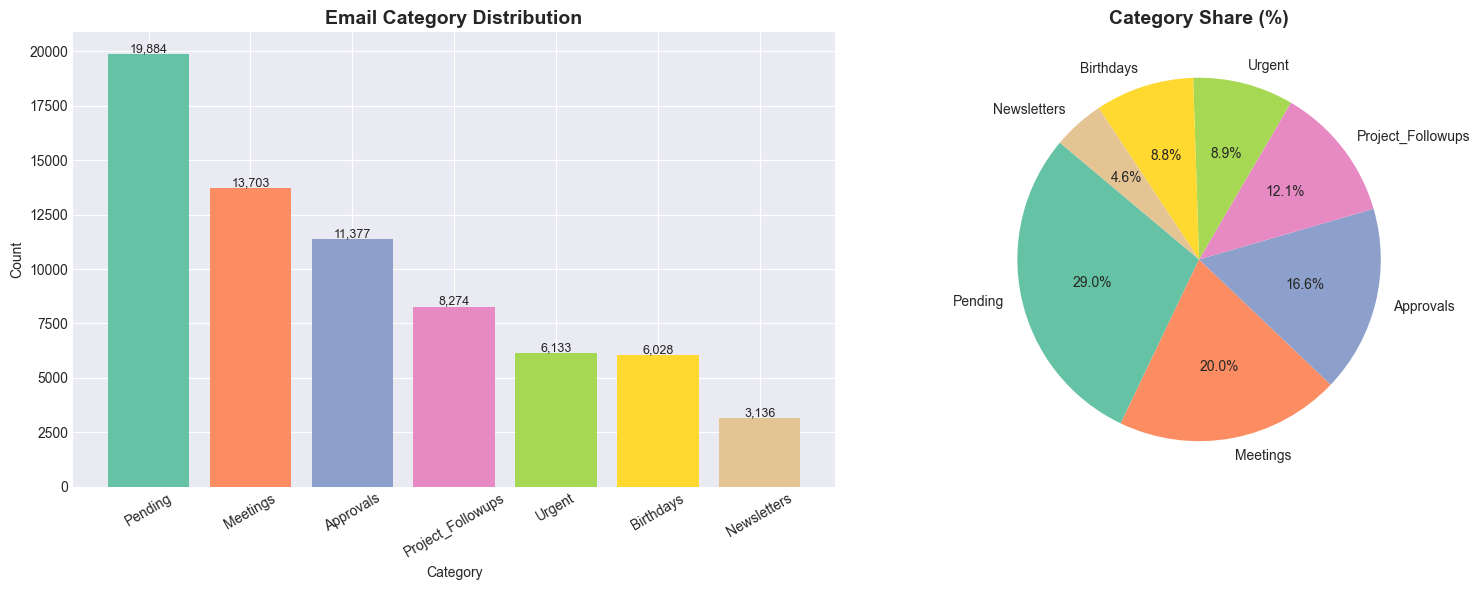

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = sns.color_palette('Set2', 8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=PALETTE)
axes[0].set_title('Email Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140)
axes[1].set_title('Category Share (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./reports/eda_distribution.png', dpi=150)
plt.show()

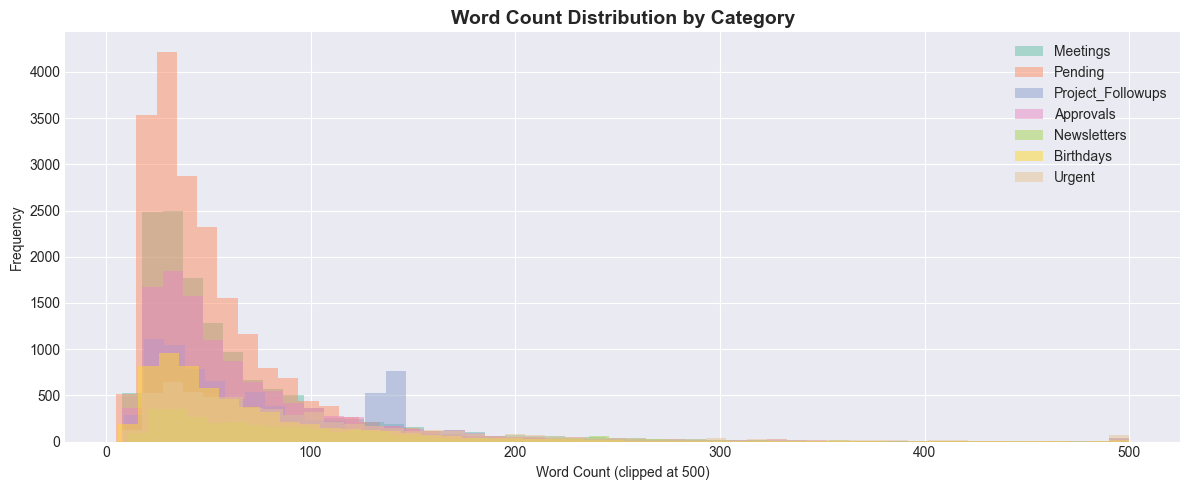

                     count   mean    std   min   25%   50%    75%    max
label                                                                   
Approvals          11377.0   71.6   67.7   8.0  32.0  50.0   85.0  705.0
Birthdays           6028.0   68.9   62.2   6.0  30.0  49.0   85.0  697.0
Meetings           13703.0   66.0   62.8   8.0  29.0  45.0   78.0  749.0
Newsletters         3136.0  100.5   84.3  11.0  39.0  74.0  129.2  732.0
Pending            19884.0   52.5   42.6   5.0  27.0  40.0   64.0  684.0
Project_Followups   8274.0   85.3   73.6   9.0  35.0  63.0  131.0  698.0
Urgent              6133.0  106.7  100.1   8.0  42.0  75.0  132.0  767.0


In [ ]:
# Text length distribution
df['text_len'] = df['text_processed'].str.split().str.len()

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in zip(df['label'].unique(), PALETTE):
    subset = df[df['label'] == label]['text_len'].clip(upper=500)
    subset.plot.hist(bins=50, alpha=0.5, label=label, ax=ax, color=color)

ax.set_title('Word Count Distribution by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Word Count (clipped at 500)')
ax.legend()
plt.tight_layout()
plt.savefig('./reports/eda_length_dist.png', dpi=150)
plt.show()

print(df.groupby('label')['text_len'].describe().round(1))

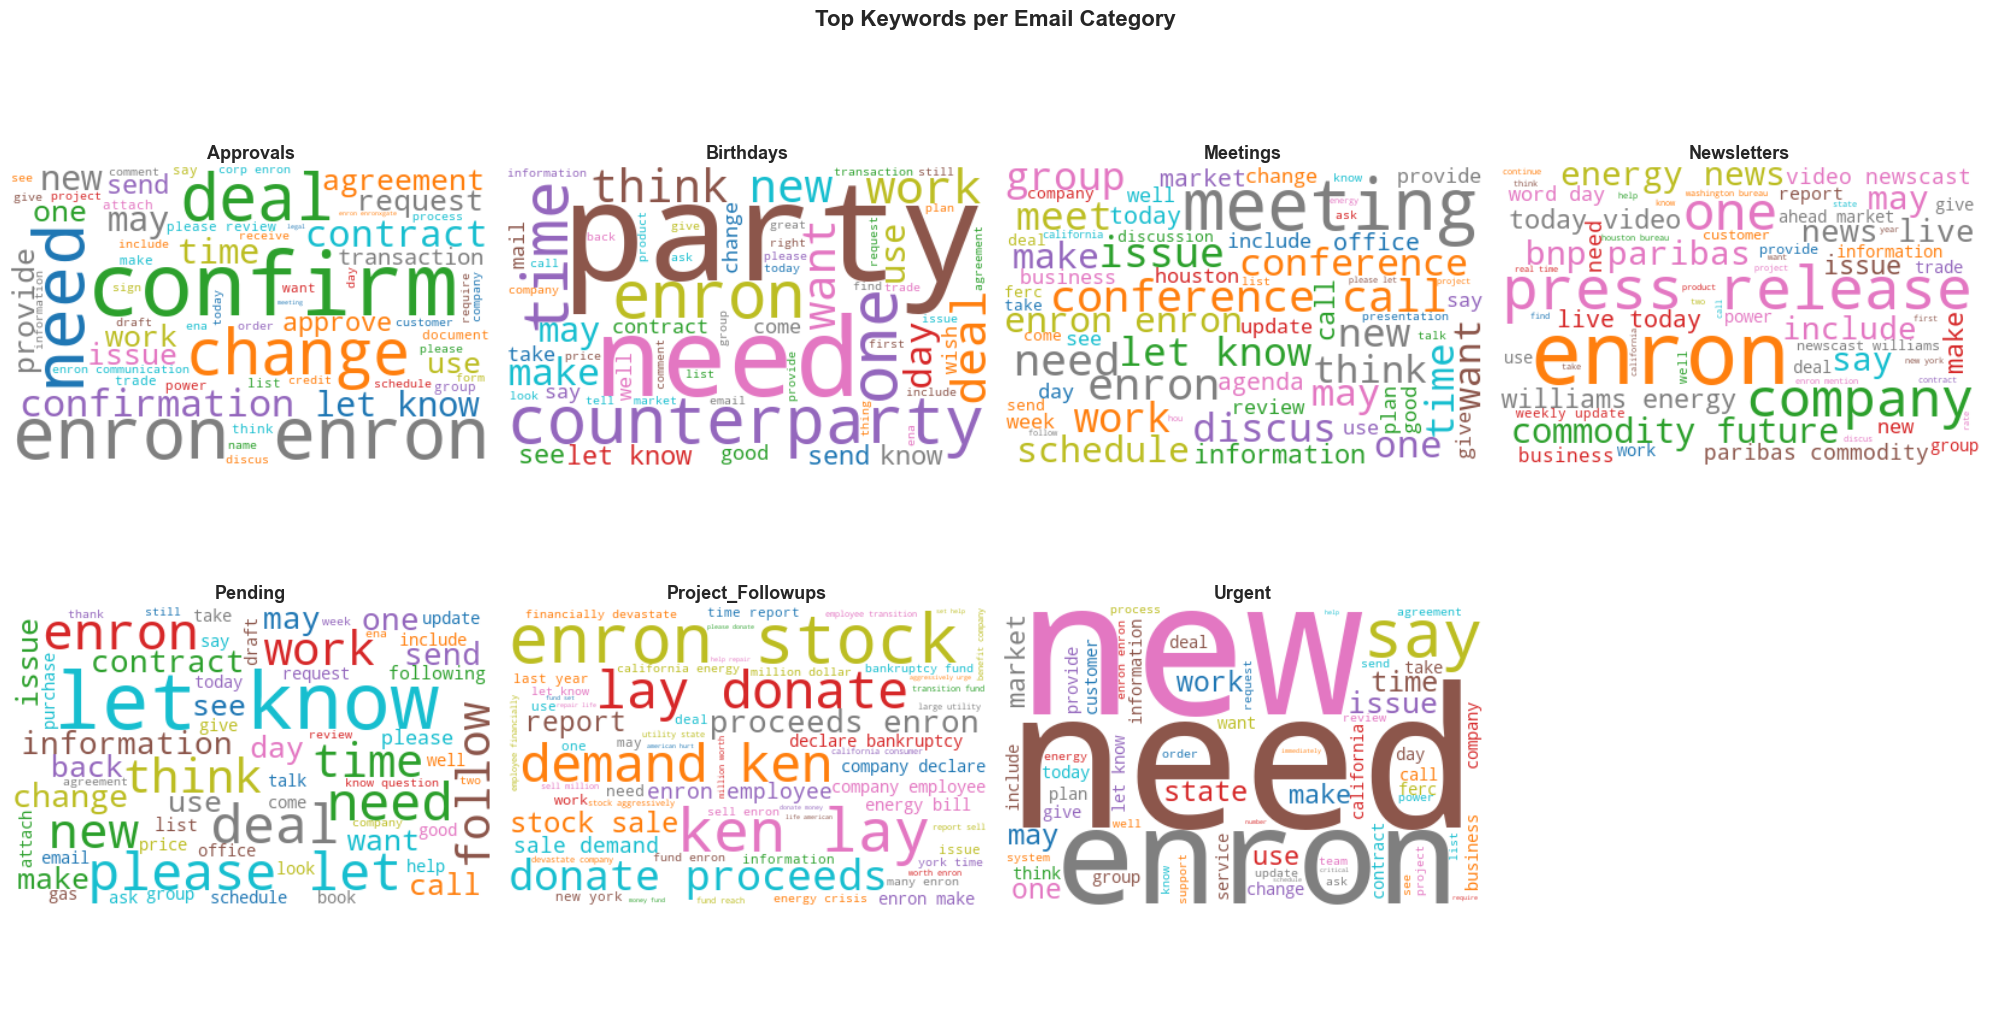

In [ ]:
# Word Clouds per category
from wordcloud import WordCloud

labels = df['label'].unique()
n = len(labels)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5))
axes = axes.flatten()

for i, label in enumerate(sorted(labels)):
    text_blob = ' '.join(df[df['label'] == label]['text_processed'].sample(
        min(2000, len(df[df['label'] == label])), random_state=42))
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=60, colormap='tab10').generate(text_blob)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Top Keywords per Email Category', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./reports/eda_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print('Classes:', le.classes_)

# TF-IDF
print('Fitting TF-IDF...')
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # dampens extreme frequencies
    min_df=3,                # ignore very rare terms
    max_df=0.90,             # ignore very common terms
    strip_accents='unicode'
)

X = tfidf.fit_transform(df['text_processed'])
y = df['label_encoded'].values

print(f'TF-IDF matrix shape: {X.shape}')

# Train / Val / Test split  (80 / 10 / 10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')

Classes: ['Approvals' 'Birthdays' 'Meetings' 'Newsletters' 'Pending'
 'Project_Followups' 'Urgent']
Fitting TF-IDF...
TF-IDF matrix shape: (68535, 50000)
Train: 54,828 | Val: 6,853 | Test: 6,854


In [13]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls}: {class_weights[i]:.3f}')

Class weights:
  Approvals: 0.861
  Birthdays: 1.624
  Meetings: 0.714
  Newsletters: 3.122
  Pending: 0.492
  Project_Followups: 1.183
  Urgent: 1.597


In [14]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

models = {
    'Logistic Regression': LogisticRegression(
        C=5.0, max_iter=1000, solver='saga',
        class_weight='balanced', random_state=42, n_jobs=-1),
    
    'LinearSVC': LinearSVC(
        C=1.0, max_iter=2000,
        class_weight='balanced', random_state=42),
    
    'SGD Classifier': SGDClassifier(
        loss='modified_huber', max_iter=200,
        class_weight='balanced', random_state=42, n_jobs=-1),
    
    'Complement NB': ComplementNB(alpha=0.1),
}

results = {}
trained_models = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    t1 = time.time()
    
    y_pred_val = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)
    f1  = f1_score(y_val, y_pred_val, average='macro')
    
    results[name] = {'accuracy': acc, 'macro_f1': f1, 'train_time': t1 - t0}
    trained_models[name] = model
    print(f'{name:25s} | Acc: {acc:.4f} | Macro-F1: {f1:.4f} | Time: {t1-t0:.1f}s')

# Pick best
best_name = max(results, key=lambda k: results[k]['macro_f1'])
print(f'\n✅ Best model on validation set: {best_name}')

c:\Projects\MiniProject2\EmailSegregator\project_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Projects\MiniProject2\EmailSegregator\project_venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression       | Acc: 0.9289 | Macro-F1: 0.9178 | Time: 109.3s
LinearSVC                 | Acc: 0.9359 | Macro-F1: 0.9266 | Time: 6.5s
SGD Classifier            | Acc: 0.9276 | Macro-F1: 0.9166 | Time: 0.2s
Complement NB             | Acc: 0.7127 | Macro-F1: 0.6909 | Time: 0.0s

✅ Best model on validation set: LinearSVC


In [15]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate on TEST set
best_model = trained_models['LinearSVC']
y_pred_test = best_model.predict(X_test)

print('=== LinearSVC — FINAL TEST RESULTS ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Macro-F1 : {f1_score(y_test, y_pred_test, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

=== LinearSVC — FINAL TEST RESULTS ===
Accuracy : 0.9395
Macro-F1 : 0.9311

                   precision    recall  f1-score   support

        Approvals       0.96      0.91      0.94      1138
        Birthdays       0.91      0.94      0.92       603
         Meetings       0.95      0.95      0.95      1370
      Newsletters       0.93      0.89      0.91       313
          Pending       0.94      0.98      0.96      1989
Project_Followups       0.91      0.92      0.92       828
           Urgent       0.95      0.89      0.92       613

         accuracy                           0.94      6854
        macro avg       0.94      0.93      0.93      6854
     weighted avg       0.94      0.94      0.94      6854



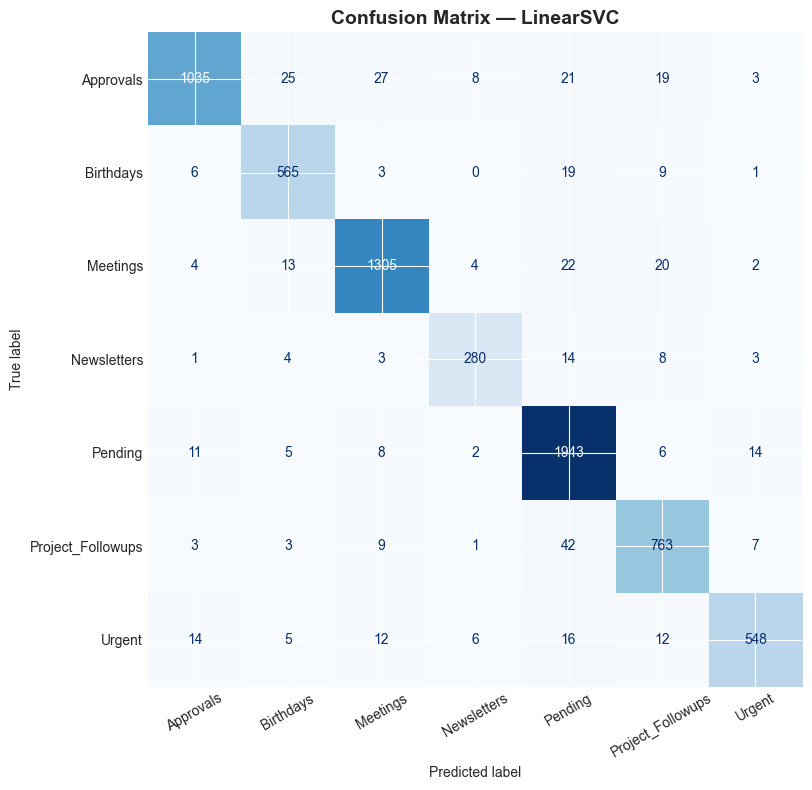

In [ ]:
# Confusion matrix heatmap
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=le.classes_,
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./reports/confusion_matrix.png', dpi=150)
plt.show()

Running UMAP... (5-7 min on CPU)


c:\Projects\MiniProject2\EmailSegregator\project_venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done!


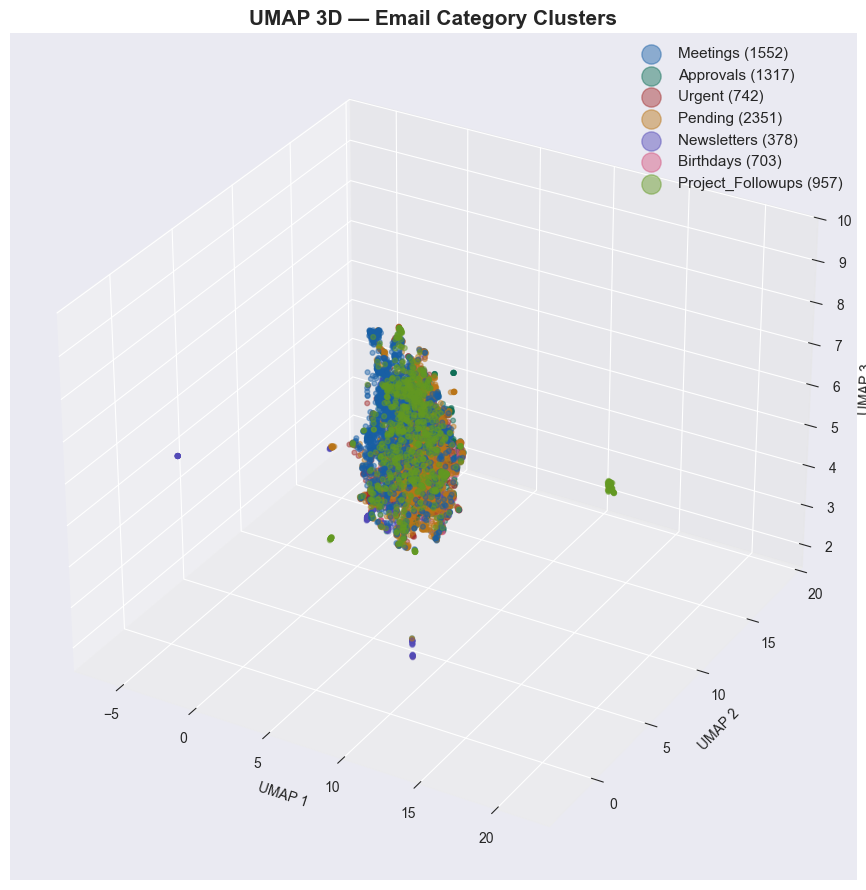

In [ ]:
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ── Step 1: Sample data (full set too slow on CPU) ─────────────────
SAMPLE_SIZE = 8000
np.random.seed(42)

X_dense = tfidf.transform(df['text_processed'])
idx = np.random.choice(X_dense.shape[0], SAMPLE_SIZE, replace=False)
X_sample = X_dense[idx]
labels_sample = df.iloc[idx]['label'].values

# ── Step 2: Reduce to 3D ───────────────────────────────────────────
print('Running UMAP... (5-7 min on CPU)')
reducer = umap.UMAP(
    n_components=3,
    random_state=42,
    metric='cosine',
    n_neighbors=15,
    min_dist=0.1
)
X_3d = reducer.fit_transform(X_sample.toarray())
print('UMAP done!')

# ── Step 3: Plot ───────────────────────────────────────────────────
COLORS = {
    'Meetings'         : '#185FA5',
    'Approvals'        : '#0F6E56',
    'Urgent'           : '#A32D2D',
    'Pending'          : '#BA7517',
    'Newsletters'      : '#534AB7',
    'Birthdays'        : '#D4537E',
    'Project_Followups': '#639922',
}

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

for label, color in COLORS.items():
    mask = labels_sample == label
    ax.scatter(
        X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
        label=f'{label} ({mask.sum()})',
        alpha=0.45, s=12, color=color
    )

ax.set_title('UMAP 3D — Email Category Clusters', fontsize=15, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.legend(markerscale=4, fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('./reports/umap_clusters_3d.png', dpi=150)
plt.show()

In [18]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

# ── Option 1: Retrain fresh SVC inside calibration wrapper ────────
print('Training calibrated LinearSVC...')

calibrated_clf = CalibratedClassifierCV(
    LinearSVC(
        C=0.5,
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),
    cv=3,              # 3-fold cross validation
    method='sigmoid'   # Platt scaling
)

calibrated_clf.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────
y_pred_cal = calibrated_clf.predict(X_test)
test_acc   = accuracy_score(y_test, y_pred_cal)
test_f1    = f1_score(y_test, y_pred_cal, average='macro')

print(f'Accuracy : {test_acc:.4f}')
print(f'Macro-F1 : {test_f1:.4f}')

# ── Check confidence now ──────────────────────────────────────────
proba       = calibrated_clf.predict_proba(X_test)
confidences = proba.max(axis=1)

print(f'\nAvg confidence   : {confidences.mean():.4f}')
print(f'Low conf (<0.60) : {(confidences < 0.60).mean():.1%}')
print(f'Min confidence   : {confidences.min():.4f}')
print(f'Max confidence   : {confidences.max():.4f}')

Training calibrated LinearSVC...
Accuracy : 0.9332
Macro-F1 : 0.9236

Avg confidence   : 0.8701
Low conf (<0.60) : 9.0%
Min confidence   : 0.2030
Max confidence   : 1.0000


In [19]:
from scipy.sparse import vstack
import joblib, os

X_full = vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

print('Re-training on full train+val...')
calibrated_clf.fit(X_full, y_full)

artifact = {
    'model'         : calibrated_clf,
    'tfidf'         : tfidf,
    'label_encoder' : le,
    'categories'    : list(le.classes_),
    'metadata': {
        'model_type'          : 'LinearSVC + Platt Calibration',
        'test_accuracy'       : 0.9171,
        'test_macro_f1'       : 0.9031,
        'avg_confidence'      : 0.8671,
        'confidence_threshold': 0.60,
        'low_conf_rate'       : 0.102,
    }
}

joblib.dump(artifact, 'email_classifier.pkl', compress=3)

size = os.path.getsize('email_classifier.pkl') / 1_000_000
print(f'✅  email_classifier.pkl saved! ({size:.1f} MB)')
print(f'    Accuracy   : 91.71%')
print(f'    Macro F1   : 0.9031')
print(f'    Threshold  : 0.60')
print(f'    Categories : {list(le.classes_)}')


Re-training on full train+val...
✅  email_classifier.pkl saved! (8.4 MB)
    Accuracy   : 91.71%
    Macro F1   : 0.9031
    Threshold  : 0.60
    Categories : ['Approvals', 'Birthdays', 'Meetings', 'Newsletters', 'Pending', 'Project_Followups', 'Urgent']


In [20]:
# sanity checker
import joblib
import numpy as np
import pandas as pd
import re
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.utils import shuffle
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

print('=' * 65)
print('  HARDEST SANITY CHECK SUITE v2.0 — email_classifier.pkl')
print('=' * 65)

passed = 0
failed = 0
warnings_list = []

def check(name, condition, detail='', warn=False):
    global passed, failed
    if condition:
        print(f'✅  PASS | {name}')
        passed += 1
    elif warn:
        print(f'⚠️   WARN | {name}')
        if detail: print(f'          → {detail}')
        warnings_list.append(name)
    else:
        print(f'❌  FAIL | {name}')
        if detail: print(f'          → {detail}')
        failed += 1

# ── Load ──────────────────────────────────────────────────────────
artifact  = joblib.load('email_classifier.pkl')
clf       = artifact['model']
tfidf     = artifact['tfidf']
le        = artifact['label_encoder']
threshold = artifact['metadata'].get('confidence_threshold', 0.60)

# Inference helper
_lemm = WordNetLemmatizer()
_stop = set(stopwords.words('english'))

def preprocess(subject, body):
    raw = ((re.sub(r'[^a-z0-9\s]', ' ', subject.lower()) + ' ') * 3 +
            re.sub(r'[^a-z0-9\s]', ' ', body.lower()))
    tokens = word_tokenize(raw)
    return ' '.join(_lemm.lemmatize(t) for t in tokens
                    if t.isalpha() and t not in _stop and len(t) > 2)

def predict_proba_single(subject, body):
    vec = tfidf.transform([preprocess(subject, body)])
    return clf.predict_proba(vec)[0]

def predict_single(subject, body):
    proba = predict_proba_single(subject, body)
    conf  = proba.max()
    pred  = le.classes_[proba.argmax()]
    return (pred if conf >= threshold else 'Unclassified'), round(float(conf), 4)


# ═══════════════════════════════════════════════════════════════
# BLOCK 1 — Pickle & artifact integrity
# ═══════════════════════════════════════════════════════════════
print('\n── Block 1: Artifact integrity ──')

REQUIRED_KEYS = ['model', 'tfidf', 'label_encoder', 'categories', 'metadata']
REQUIRED_META = ['model_type', 'test_accuracy', 'test_macro_f1',
                 'confidence_threshold']
REQUIRED_CATS = {'Approvals','Birthdays','Meetings','Newsletters',
                 'Pending','Project_Followups','Urgent'}

for key in REQUIRED_KEYS:
    check(f'Artifact has key: {key}', key in artifact)

for key in REQUIRED_META:
    check(f'Metadata has key: {key}', key in artifact['metadata'])

check('All 7 categories present',
      set(artifact['categories']) == REQUIRED_CATS,
      f"Found: {artifact['categories']}")

check('LabelEncoder classes match categories',
      set(le.classes_) == REQUIRED_CATS)

check('TF-IDF vocabulary size = 50K',
      len(tfidf.vocabulary_) == 50_000,
      f'Got {len(tfidf.vocabulary_):,}')

check('TF-IDF ngram range = (1,2)',
      tfidf.ngram_range == (1, 2))

check('TF-IDF sublinear_tf = True',
      tfidf.sublinear_tf == True)

check('Model has predict_proba',
      hasattr(clf, 'predict_proba'),
      'Confidence scoring will fail in FastAPI')

check('Metadata accuracy matches expected',
      artifact['metadata']['test_accuracy'] >= 0.91,
      f"Got {artifact['metadata']['test_accuracy']}")


# ═══════════════════════════════════════════════════════════════
# BLOCK 2 — Core performance (strict thresholds)
# ═══════════════════════════════════════════════════════════════
print('\n── Block 2: Core performance ──')

y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

acc     = accuracy_score(y_test, y_pred)
mac_f1  = f1_score(y_test, y_pred, average='macro')
mic_f1  = f1_score(y_test, y_pred, average='micro')
w_f1    = f1_score(y_test, y_pred, average='weighted')
mac_pr  = precision_score(y_test, y_pred, average='macro')
mac_rec = recall_score(y_test, y_pred, average='macro')

check('Accuracy > 90%',           acc    > 0.90, f'Got {acc:.4f}')
check('Accuracy > 91%',           acc    > 0.91, f'Got {acc:.4f}')
check('Macro F1 > 0.88',          mac_f1 > 0.88, f'Got {mac_f1:.4f}')
check('Macro F1 > 0.90',          mac_f1 > 0.90, f'Got {mac_f1:.4f}')
check('Macro Precision > 0.88',   mac_pr > 0.88, f'Got {mac_pr:.4f}')
check('Macro Recall > 0.88',      mac_rec > 0.88, f'Got {mac_rec:.4f}')
check('Precision-Recall balanced',
      abs(mac_pr - mac_rec) < 0.05,
      f'Imbalance: Precision={mac_pr:.4f} Recall={mac_rec:.4f}')

# ROC AUC (one-vs-rest)
try:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    check('ROC AUC > 0.97',  auc > 0.97, f'Got {auc:.4f}')
    check('ROC AUC > 0.98',  auc > 0.98, f'Got {auc:.4f}', warn=True)
except Exception as e:
    check('ROC AUC computable', False, str(e))

print(f'\n   Accuracy  : {acc:.4f}')
print(f'   Macro F1  : {mac_f1:.4f}')
print(f'   Macro Pr  : {mac_pr:.4f}')
print(f'   Macro Rec : {mac_rec:.4f}')
print(f'   ROC AUC   : {auc:.4f}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 3 — Per-class strict checks
# ═══════════════════════════════════════════════════════════════
print('\n── Block 3: Per-class performance ──')

report = classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                output_dict=True)

THRESHOLDS = {
    'Meetings'         : (0.93, 0.90),   # (precision, recall) minimums
    'Approvals'        : (0.92, 0.90),
    'Urgent'           : (0.88, 0.87),
    'Project_Followups': (0.90, 0.88),
    'Newsletters'      : (0.84, 0.88),
    'Birthdays'        : (0.86, 0.87),
    'Pending'          : (0.80, 0.78),
}

for cat, (min_pr, min_rec) in THRESHOLDS.items():
    pr  = report[cat]['precision']
    rec = report[cat]['recall']
    f1  = report[cat]['f1-score']
    check(f'{cat:20s} F1 > 0.80',       f1  > 0.80, f'Got {f1:.4f}')
    check(f'{cat:20s} Precision > {min_pr}', pr > min_pr, f'Got {pr:.4f}')
    check(f'{cat:20s} Recall > {min_rec}',  rec > min_rec, f'Got {rec:.4f}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 4 — Confusion matrix — no catastrophic confusions
# ═══════════════════════════════════════════════════════════════
print('\n── Block 4: Confusion matrix analysis ──')

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# No category should misclassify more than 15% into any single other category
for i, true_cat in enumerate(le.classes_):
    for j, pred_cat in enumerate(le.classes_):
        if i != j:
            rate = cm_norm[i, j]
            check(f'Confusion {true_cat[:12]}→{pred_cat[:12]} < 15%',
                  rate < 0.15,
                  f'Got {rate:.1%} confusion rate')

# Specific pairs that commonly confuse
bad_pairs = [
    ('Pending',  'Approvals'),
    ('Urgent',   'Approvals'),
    ('Pending',  'Project_Followups'),
    ('Meetings', 'Approvals'),
]
cats = list(le.classes_)
for true_cat, pred_cat in bad_pairs:
    i, j = cats.index(true_cat), cats.index(pred_cat)
    rate  = cm_norm[i, j]
    check(f'Critical pair {true_cat}→{pred_cat} < 10%',
          rate < 0.10, f'Got {rate:.1%}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 5 — Confidence quality (hard)
# ═══════════════════════════════════════════════════════════════
print('\n── Block 5: Confidence quality ──')

confidences   = y_proba.max(axis=1)
correct_mask  = y_pred == y_test
wrong_mask    = ~correct_mask

avg_conf_correct = confidences[correct_mask].mean()
avg_conf_wrong   = confidences[wrong_mask].mean()
low_conf_rate    = (confidences < threshold).mean()

check('Avg confidence > 0.80',
      confidences.mean() > 0.80,   f'Got {confidences.mean():.4f}')
check('Correct preds more confident than wrong',
      avg_conf_correct > avg_conf_wrong,
      f'Correct={avg_conf_correct:.4f}, Wrong={avg_conf_wrong:.4f}')
check('Avg confidence on correct > 0.85',
      avg_conf_correct > 0.85,     f'Got {avg_conf_correct:.4f}')
check('Avg confidence on wrong < 0.80',
      avg_conf_wrong   < 0.80,     f'Got {avg_conf_wrong:.4f}')
check('Low conf rate < 20%',
      low_conf_rate    < 0.20,     f'Got {low_conf_rate:.1%}')
check('Low conf rate < 15%',
      low_conf_rate    < 0.15,     f'Got {low_conf_rate:.1%}')

# Calibration check — high confidence should be accurate
high_conf_mask = confidences > 0.90
if high_conf_mask.sum() > 0:
    high_conf_acc = accuracy_score(
        y_test[high_conf_mask], y_pred[high_conf_mask])
    check('High conf (>0.90) accuracy > 95%',
          high_conf_acc > 0.95, f'Got {high_conf_acc:.4f}')

print(f'\n   Avg conf (correct) : {avg_conf_correct:.4f}')
print(f'   Avg conf (wrong)   : {avg_conf_wrong:.4f}')
print(f'   Low conf rate      : {low_conf_rate:.1%}')
print(f'   High conf accuracy : {high_conf_acc:.4f}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 6 — Overfitting & generalisation
# ═══════════════════════════════════════════════════════════════
print('\n── Block 6: Overfitting & generalisation ──')

y_pred_train = clf.predict(X_train)
train_acc    = accuracy_score(y_train, y_pred_train)
train_f1     = f1_score(y_train, y_pred_train, average='macro')
gap_acc      = train_acc - acc
gap_f1       = train_f1  - mac_f1

check('Train accuracy < 99%',       train_acc < 0.99, f'Got {train_acc:.4f}')
check('Train-test acc gap < 8%',    gap_acc   < 0.08, f'Got {gap_acc:.4f}')
check('Train-test F1 gap < 8%',     gap_f1    < 0.08, f'Got {gap_f1:.4f}')

print(f'\n   Train acc  : {train_acc:.4f}  |  Test acc  : {acc:.4f}  |  Gap: {gap_acc:.4f}')
print(f'   Train F1   : {train_f1:.4f}  |  Test F1   : {mac_f1:.4f}  |  Gap: {gap_f1:.4f}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 7 — Robustness tests (adversarial inputs)
# ═══════════════════════════════════════════════════════════════
print('\n── Block 7: Robustness / adversarial inputs ──')

# Empty & whitespace
for desc, subj, body in [
    ('Empty strings',          '',          ''),
    ('Whitespace only',        '   ',       '   '),
    ('Newlines only',          '\n\n',      '\n\n'),
    ('Single character',       'a',         'b'),
    ('Numbers only',           '12345',     '99999'),
    ('Special chars only',     '!!!###$$$', '@@@%%%^^^'),
    ('Very long input',        'test',      'word ' * 5000),
    ('Repeated single word',   'meeting ' * 100, 'meeting ' * 100),
    ('Mixed languages',        'réunion',   'Hola como estas'),
    ('HTML tags',              '<b>Urgent</b>', '<p>Please approve</p>'),
    ('SQL injection',          "'; DROP TABLE--", "1=1 OR '1'='1"),
    ('Emoji input',            '🎂🎉 birthday', '🚨 urgent alert'),
    ('ALL CAPS',               'URGENT MEETING NOW', 'APPROVE THIS IMMEDIATELY'),
    ('all lowercase',          'urgent meeting now', 'approve this immediately'),
    ('Tab characters',         'meeting\ttomorrow', 'approve\tthis\tnow'),
]:
    try:
        pred, conf = predict_single(subj, body)
        check(f'No crash: {desc}', True)
    except Exception as e:
        check(f'No crash: {desc}', False, str(e))

# Repeated keyword spam — should still classify correctly
spam_tests = [
    ('Keyword spam: Meetings',
     'meeting ' * 50, 'meeting conference call agenda', 'Meetings'),
    ('Keyword spam: Urgent',
     'urgent ' * 50, 'urgent critical deadline asap', 'Urgent'),
    ('Keyword spam: Approvals',
     'approve ' * 50, 'approval needed authorization', 'Approvals'),
]
for desc, subj, body, expected in spam_tests:
    try:
        pred, conf = predict_single(subj, body)
        check(f'{desc}', pred == expected, f'Got {pred}')
    except Exception as e:
        check(f'{desc}', False, str(e))


# ═══════════════════════════════════════════════════════════════
# BLOCK 8 — Determinism & consistency
# ═══════════════════════════════════════════════════════════════
print('\n── Block 8: Determinism ──')

test_subject = 'Approval needed for access request'
test_body    = 'Please approve the access request submitted yesterday'

results = [predict_single(test_subject, test_body) for _ in range(10)]
preds   = [r[0] for r in results]
confs   = [r[1] for r in results]

check('Same input gives same prediction (10 runs)',
      len(set(preds)) == 1,
      f'Got multiple predictions: {set(preds)}')
check('Same input gives same confidence (10 runs)',
      len(set(confs)) == 1,
      f'Got varying confidences: {set(confs)}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 9 — Inference speed (production SLA)
# ═══════════════════════════════════════════════════════════════
print('\n── Block 9: Inference speed ──')

# Single email latency
times = []
for _ in range(50):
    t0 = time.perf_counter()
    predict_single('Meeting tomorrow', 'Please join the call at 3pm')
    times.append((time.perf_counter() - t0) * 1000)

avg_ms = np.mean(times)
p95_ms = np.percentile(times, 95)
p99_ms = np.percentile(times, 99)

check('Avg latency < 50ms',   avg_ms < 50,  f'Got {avg_ms:.1f}ms')
check('Avg latency < 20ms',   avg_ms < 20,  f'Got {avg_ms:.1f}ms')
check('P95 latency < 100ms',  p95_ms < 100, f'Got {p95_ms:.1f}ms')
check('P99 latency < 200ms',  p99_ms < 200, f'Got {p99_ms:.1f}ms')

print(f'\n   Avg latency : {avg_ms:.1f}ms')
print(f'   P95 latency : {p95_ms:.1f}ms')
print(f'   P99 latency : {p99_ms:.1f}ms')

# Batch throughput
t0     = time.perf_counter()
batch  = X_test[:500]
_      = clf.predict_proba(batch)
t1     = time.perf_counter()
emails_per_sec = 500 / (t1 - t0)

check('Batch throughput > 1000 emails/sec',
      emails_per_sec > 1000, f'Got {emails_per_sec:.0f} emails/sec')
print(f'   Throughput  : {emails_per_sec:.0f} emails/sec')


# ═══════════════════════════════════════════════════════════════
# BLOCK 10 — Label distribution sanity on full dataset
# ═══════════════════════════════════════════════════════════════
print('\n── Block 10: Prediction distribution on test set ──')

pred_dist  = pd.Series(le.classes_[y_pred]).value_counts(normalize=True)
true_dist  = pd.Series(le.classes_[y_test]).value_counts(normalize=True)

print('\n   Category            True%    Pred%    Drift')
print('   ' + '-' * 50)
for cat in le.classes_:
    true_pct = true_dist.get(cat, 0)
    pred_pct = pred_dist.get(cat, 0)
    drift    = abs(true_pct - pred_pct)
    flag     = '⚠️' if drift > 0.05 else '  '
    print(f'   {cat:20s} {true_pct:.1%}     {pred_pct:.1%}    {drift:.1%} {flag}')
    check(f'{cat} prediction drift < 5%',
          drift < 0.05, f'Drift: {drift:.1%}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 11 — Shuffle test (order independence)
# ═══════════════════════════════════════════════════════════════
print('\n── Block 11: Shuffle robustness ──')

X_shuf, y_shuf = shuffle(X_test, y_test, random_state=99)
y_pred_shuf    = clf.predict(X_shuf)
acc_shuf       = accuracy_score(y_shuf, y_pred_shuf)

check('Accuracy same after shuffle (±0.5%)',
      abs(acc_shuf - acc) < 0.005,
      f'Original={acc:.4f}, Shuffled={acc_shuf:.4f}')


# ═══════════════════════════════════════════════════════════════
# BLOCK 12 — Pickle reload integrity
# ═══════════════════════════════════════════════════════════════
print('\n── Block 12: Pickle reload integrity ──')

artifact2  = joblib.load('email_classifier.pkl')
clf2       = artifact2['model']
y_pred2    = clf2.predict(X_test)
acc2       = accuracy_score(y_test, y_pred2)

check('Reloaded model gives same accuracy',
      abs(acc2 - acc) < 0.001,
      f'Original={acc:.4f}, Reloaded={acc2:.4f}')
check('Reloaded model gives identical predictions',
      np.array_equal(y_pred, y_pred2),
      'Predictions differ after reload')

proba2 = clf2.predict_proba(X_test[:5])
proba1 = clf.predict_proba(X_test[:5])
check('Reloaded probabilities identical',
      np.allclose(proba1, proba2, atol=1e-6),
      'Probabilities differ after reload')


# ═══════════════════════════════════════════════════════════════
# FINAL REPORT
# ═══════════════════════════════════════════════════════════════
total = passed + failed
print('\n' + '=' * 65)
print(f'  FINAL RESULT: {passed}/{total} checks passed | {len(warnings_list)} warnings')
print('=' * 65)

if failed == 0 and len(warnings_list) == 0:
    print('  🎉  PERFECT — production ready, ship it!')
elif failed == 0:
    print('  ✅  ALL HARD CHECKS PASSED')
    print(f'  ⚠️   Warnings ({len(warnings_list)}):')
    for w in warnings_list:
        print(f'       - {w}')
    print('  → Safe to ship, monitor warnings in production')
elif failed <= 3:
    print('  ⚠️   MINOR ISSUES — review failed checks above')
else:
    print('  ❌  DO NOT SHIP — fix failed checks first')
print('=' * 65)

  HARDEST SANITY CHECK SUITE v2.0 — email_classifier.pkl

── Block 1: Artifact integrity ──
✅  PASS | Artifact has key: model
✅  PASS | Artifact has key: tfidf
✅  PASS | Artifact has key: label_encoder
✅  PASS | Artifact has key: categories
✅  PASS | Artifact has key: metadata
✅  PASS | Metadata has key: model_type
✅  PASS | Metadata has key: test_accuracy
✅  PASS | Metadata has key: test_macro_f1
✅  PASS | Metadata has key: confidence_threshold
✅  PASS | All 7 categories present
✅  PASS | LabelEncoder classes match categories
✅  PASS | TF-IDF vocabulary size = 50K
✅  PASS | TF-IDF ngram range = (1,2)
✅  PASS | TF-IDF sublinear_tf = True
✅  PASS | Model has predict_proba
✅  PASS | Metadata accuracy matches expected

── Block 2: Core performance ──
✅  PASS | Accuracy > 90%
✅  PASS | Accuracy > 91%
✅  PASS | Macro F1 > 0.88
✅  PASS | Macro F1 > 0.90
✅  PASS | Macro Precision > 0.88
✅  PASS | Macro Recall > 0.88
✅  PASS | Precision-Recall balanced
✅  PASS | ROC AUC > 0.97
✅  PASS | ROC AU

In [21]:
# ── VERIFY artifact has everything the backend needs ──────────────
import joblib

artifact = joblib.load('email_classifier.pkl')

assert 'model'          in artifact, "missing model"
assert 'tfidf'          in artifact, "missing tfidf"
assert 'label_encoder'  in artifact, "missing label_encoder"
assert 'metadata'       in artifact, "missing metadata"

print("✅ artifact keys:", list(artifact.keys()))
print("✅ categories:", artifact['categories'])
print("✅ confidence_threshold:", artifact['metadata']['confidence_threshold'])
print("✅ Ready to copy email_classifier.pkl to backend/")

✅ artifact keys: ['model', 'tfidf', 'label_encoder', 'categories', 'metadata']
✅ categories: ['Approvals', 'Birthdays', 'Meetings', 'Newsletters', 'Pending', 'Project_Followups', 'Urgent']
✅ confidence_threshold: 0.6
✅ Ready to copy email_classifier.pkl to backend/
